In [1]:
import sys
sys.path.append('../../Simulate/')
import importlib
import SetMethylation

from SetMethylation import SetMethylation
from ParseGenome import ParseGenome
from Bio import SeqIO

# test random dist

In [2]:
working_path = "/home/wbguo/iproject/BSReadSim/test/"
ref_fasta = working_path + "data/ref/BSB_test.fa"
cgmap_file= working_path + "data/sim/pe_d/sim.CGmap.gz"
asm_file  = working_path + "data/sim/pe_d/sim.asm.gz"

outdir = working_path + "outdir/"
ref_dict  = SeqIO.to_dict(SeqIO.parse(ref_fasta, "fasta"))

In [3]:
meth_set = SetMethylation(ref_dict=ref_dict, 
                          outdir=outdir, overwrite_db=True)

In [40]:
meth_set.__dict__

{'ref_dict': {'chr10': SeqRecord(seq=Seq('ACTTGCCACTAGAGGAAACCTCACTGATAAAGAGTTAACTGTGTCATTTACCTG...GCT'), id='chr10', name='chr10', description='chr10', dbxrefs=[]),
  'chr11': SeqRecord(seq=Seq('ACTGGAAGGAGAATGGTTAGGACGGGTCCTAGGAGTGGGAGTAACCAGGATTAC...CCC'), id='chr11', name='chr11', description='chr11', dbxrefs=[]),
  'chr12': SeqRecord(seq=Seq('AACCCACTTGACCATGGTGTTTTTTCTTTTCTATATGCTCTGGAATTGGTTTCT...GTA'), id='chr12', name='chr12', description='chr12', dbxrefs=[]),
  'chr13': SeqRecord(seq=Seq('AGTGTGAGAATGGAAGGCTCTTCTTCAAACTATGCAAAATGAATCAATCAAAAG...GGC'), id='chr13', name='chr13', description='chr13', dbxrefs=[]),
  'chr14': SeqRecord(seq=Seq('GTTGTGTGCCACCAGGCCTGGCTAATTTTTGTATTTTTACTTGAGATGGGCATG...GTC'), id='chr14', name='chr14', description='chr14', dbxrefs=[]),
  'chr15': SeqRecord(seq=Seq('ACTTGCCACTAGAGGAAACCTCACTGATAAAGAGTTAACTGTGTCATTTACCTG...ACA'), id='chr15', name='chr15', description='chr15', dbxrefs=[])},
 'outdir': '/home/wbguo/iproject/BSReadSim/test/outdir/',
 'met

In [4]:
meth_set = SetMethylation(ref_dict=ref_dict, 
                          outdir=outdir,overwrite_db=True, verbose=True)


[Initiating meth_db] for chr10...
Filling with beta distribution for chr10...
Processed 187408 sites from contig chr10

[Initiating meth_db] for chr11...
Filling with beta distribution for chr11...
Processed 187844 sites from contig chr11

[Initiating meth_db] for chr12...
Filling with beta distribution for chr12...
Processed 184249 sites from contig chr12

[Initiating meth_db] for chr13...
Filling with beta distribution for chr13...
Processed 142075 sites from contig chr13

[Initiating meth_db] for chr14...
Filling with beta distribution for chr14...
Processed 154158 sites from contig chr14

[Initiating meth_db] for chr15...
Filling with beta distribution for chr15...
Processed 2252 sites from contig chr15


In [5]:
meth_set.meth_arr[1:40, ]

array([[1.50000000e+01, 0.00000000e+00, 3.39654070e-35, 3.39654070e-35,
        3.39654070e-35],
       [7.00000000e+00, 0.00000000e+00, 4.17944195e-31, 4.17944195e-31,
        4.17944195e-31],
       [7.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [7.00000000e+00, 0.00000000e+00, 1.05486131e-09, 1.05486131e-09,
        1.05486131e-09],
       [1.50000000e+01, 0.00000000e+00, 9.99992132e-01, 9.99992132e-01,
        9.99992132e-01],
       [1.50000000e+01, 0.00000000e+00, 9.99910057e-01, 9.99910057e-01,
        9.99910057e-01],
       [1.50000000e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [7.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [7.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [7.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [3.00000000e+00, 0.0000

In [6]:
meth_set.arr_max_size

[424000, 187844]

In [7]:
meth_set.meth_arr[2]

array([7.000000e+00, 0.000000e+00, 4.179442e-31, 4.179442e-31,
       4.179442e-31], dtype=float32)

In [8]:
pos_map, meth_arr, _ =  meth_set.meth_db.load_contig("chr10")

In [9]:
meth_set.meth_db.create_share_arr([10**6, 10**6*5])
meth_set.meth_db.load_contig_share("chr10")

In [10]:
from pympler import asizeof
print(asizeof.asizeof(meth_set))

2040464


(array([146789.,   2117.,   1483.,   1306.,   1226.,   1236.,   1289.,
          1516.,   2019.,  28427.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

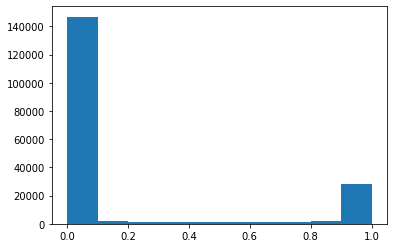

In [11]:
import matplotlib.pyplot as plt
plt.hist(meth_arr[:,2])

(array([1016.,  484.,  382.,  340.,  337.,  321.,  335.,  388.,  459.,
        1051.]),
 array([9.20031979e-08, 1.00000076e-01, 2.00000063e-01, 3.00000042e-01,
        4.00000036e-01, 5.00000000e-01, 6.00000024e-01, 6.99999988e-01,
        7.99999952e-01, 8.99999976e-01, 9.99999940e-01], dtype=float32),
 <BarContainer object of 10 artists>)

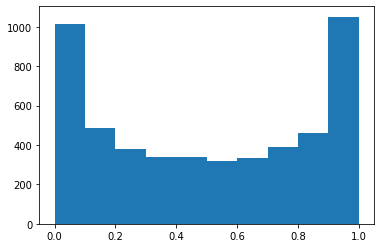

In [12]:
plt.hist(meth_arr[meth_arr[:,0] == 1, 2])

(array([16812.,   137.,   107.,    77.,    56.,    87.,    64.,    80.,
          142.,  3085.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

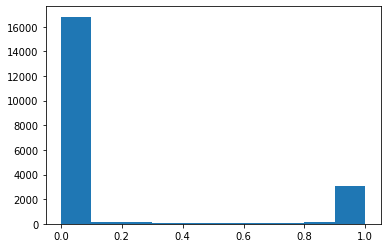

In [13]:
plt.hist(meth_arr[meth_arr[:,0] == 3,2])

(array([54905.,   447.,   306.,   212.,   240.,   225.,   240.,   281.,
          408., 10063.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

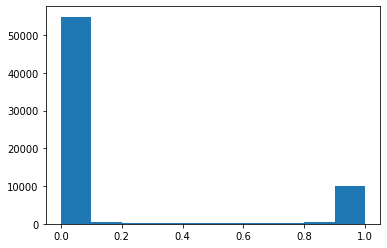

In [14]:
plt.hist(meth_arr[meth_arr[:,0] == 7,2])

# test reassign the reference reference object to another class

In [15]:
class B:
    def __init__(self, ref_dict, outdir = None, overwrite_db = False):
        self.meth_db = ref_dict

In [16]:
meth_set2 = B(ref_dict=ref_dict, 
              outdir=outdir, overwrite_db=True)

In [17]:
id(meth_set2.meth_db)

140243905908032

In [18]:
id(ref_dict)

140243905908032

# Test CGmap

In [19]:
meth_set3 = SetMethylation(ref_dict = ref_dict, cgmap_file=cgmap_file,
                           outdir=outdir, overwrite_db=True, verbose = True)


[Initiating meth_db] for chr10...
Filling CGmap for chr10... 184989 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr10...
Processed 187408 sites from contig chr10

[Initiating meth_db] for chr11...
Filling CGmap for chr11... 187526 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr11...
Processed 187844 sites from contig chr11

[Initiating meth_db] for chr12...
Filling CGmap for chr12... 183947 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr12...
Processed 184249 sites from contig chr12

[Initiating meth_db] for chr13...
Filling CGmap for chr13... 141763 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr13...
Processed 142075 sites from contig chr13

[Initiating meth_db] for chr14...
Filling CGmap for chr14... 153904 sites found in CGmap fi

In [20]:
meth_set.pos_map

array([4294967295,          0, 4294967295, ..., 4294967295,       2251,
       4294967295], dtype=uint32)

In [21]:
pos_map, meth_arr, _ = meth_set3.meth_db.load_contig('chr10')

In [22]:
# remember the position is 0-based in the code
meth_arr[pos_map[5436],:] # check the 5437, true

array([1., 1., 0., 0., 0.], dtype=float32)

In [23]:
meth_arr[pos_map[5490],:] # true

array([3., 1., 0., 0., 0.], dtype=float32)

In [24]:
meth_arr[pos_map[6230],:] # true

array([9.      , 1.      , 0.866667, 0.866667, 0.866667], dtype=float32)

# Test ASM & CGmap

In [25]:
meth_set4 = SetMethylation(ref_dict = ref_dict, cgmap_file=cgmap_file, asm_file = asm_file,
                           outdir=outdir, overwrite_db=True, verbose = True)


[Initiating meth_db] for chr10...
Filling CGmap for chr10... 184989 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling ASM for chr10... 12680 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr10...
Processed 187408 sites from contig chr10

[Initiating meth_db] for chr11...
Filling CGmap for chr11... 187526 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling ASM for chr11... 12947 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr11...
Processed 187844 sites from contig chr11

[Initiating meth_db] for chr12...
Filling CGmap for chr12... 183947 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling ASM for chr12... 12318 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr12...
Processed 184249 sites from contig chr12

[Initi

In [26]:
pos_map, meth_arr, _ = meth_set4.meth_db.load_contig('chr10')

In [27]:
meth_arr[pos_map[9360]] # check the 9360, true

array([7.       , 2.       , 0.625    , 0.6978857, 0.5521143],
      dtype=float32)

In [28]:
meth_arr[pos_map[12303]]  # check the 12304, true

array([15.        ,  2.        ,  0.333333  ,  0.40280655,  0.26385942],
      dtype=float32)

In [29]:
meth_arr[pos_map[11182]] # check the 11183, no found

array([9., 1., 1., 1., 1.], dtype=float32)

# test CGmap for chr21

In [30]:
working_path = working_path = "/home/wbguo/iproject/BSReadSim/test/"
ref_fasta = working_path + "data/ref/chr21.fa"
cgmap_file= working_path + "data/chr21/ERR2359938.CGmap.gz"

ref_dict  = SeqIO.to_dict(SeqIO.parse(ref_fasta, "fasta"))

In [31]:
meth_set5 = SetMethylation(ref_dict= ref_dict, cgmap_file=cgmap_file,
                           outdir=outdir, overwrite_db=True, verbose = True)


[Initiating meth_db] for chr21...
Filling CGmap for chr21... 1177862 sites found in CGmap file, among them 0 sites (0.0%) are incompatible...
Filling with beta distribution for chr21...
Processed 16411625 sites from contig chr21


In [32]:
print(asizeof.asizeof(meth_set5))

561789600


In [33]:
meth_set5.meth_arr.shape

(16411625, 5)

In [38]:
meth_set5.pos_map.shape

(46709983,)

In [34]:
meth_set5.arr_max_size

[46709983, 16411625]

In [35]:
print(asizeof.asizeof(meth_set5.meth_db))

1072


In [36]:
print(asizeof.asizeof(meth_set5.pos_map))

186840056


In [37]:
print(asizeof.asizeof(meth_set5.meth_arr))

328232640


# test cgmap pool

In [39]:
import SetMethylation
importlib.reload(SetMethylation)
from SetMethylation import SetMethylation
meth_set6 = SetMethylation(ref_dict= ref_dict, cgmap_file=cgmap_file, cgmap_pool = True,
                           outdir=outdir, overwrite_db=True, verbose = True)


[Initiating meth_db] for chr21...
Filling CGmap for chr21 (pool)... Processed 16411625 sites from contig chr21


# test time and mem

In [ ]:
%timeit myDict[np.random.randint(0, 10**6)]  # 5.81 us, 41943136 byte
%timeit myArr[np.random.randint(0, 10**6),:] # 6.27 us, 10000120 byte
%timeit np.where(myArr[:,0] == np.random.randint(0, 10**6)) # 4.21 ms
# pos_map = {int(i):int(i) for i in range(arr_size)}  
%timeit myArr[pos_map[np.random.randint(0, 10**6)],:] # 6.72 µs,   41943136 byte
# pd_series = pd.Series(range(arr_size), dtype = np.uint32) 
%timeit myArr[pd_series[np.random.randint(0, 10**6)],:] # 13.8 µs, 4000144 byte
## have not checked 10**7, it's generally very long

In [ ]:
# column context, row cigar
table =np.array([['M', 'c', 'C', 'b',  'B', 'a', 'A', '-',  '-', 'c', 'C', 'b',  'B', 'a', 'A', '-'], # match
                 ['x', 'x', 'X', 'x',  'X', 'x', 'X', '-',  '-', 'x', 'X', 'x',  'X', 'x', 'X', '-'], # snp
                 ['-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-'], # empty
                 ['M', 'i', 'I', 'i',  'I', 'i', 'I', '-',  '-', 'i', 'I', 'i',  'I', 'i', 'I', '-'], # insert
                 ['-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-'], # empty
                 ['-', '#', '-', '#',  '-', '#', '-', '-',  '-', '#', '-', '#',  '-', '#', '-', '-']])# convert

In [ ]:
import sys
sys.getsizeof(table)

In [ ]:
table

# test numpy & pandas series

### pandas

In [ ]:
N = 120000000
test_series = pd.Series(range(N), index=range(N), dtype=np.uint32)
test_series_swap = pd.Series(test_series.index.values, index=test_series, dtype=np.uint32)

In [ ]:
test_series 

In [ ]:
asizeof.asizeof(test_series)

In [ ]:
asizeof.asizeof(test_series_swap)

In [ ]:
%timeit x = test_series_swap[np.random.randint(low=0, high=N)]

In [ ]:
test_arr = np.dstack((test_series_swap.to_numpy(), test_series_swap.to_numpy()))
test_arr = test_arr[0]

### numpy

In [ ]:
test_arr

In [ ]:
asizeof.asizeof(test_arr)

In [ ]:
%timeit np.searchsorted(test_series_swap.to_numpy(), np.random.randint(low=0, high=N))

In [ ]:
z  = np.random.randint(low = 0, high = N, size = N, dtype=np.uint32)

In [ ]:
asizeof.asizeof(z)

In [ ]:
%timeit z[np.random.randint(low=0, high=N)]